In [ ]:
import numpy as np
print(np.__version__)

1.26.4


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Torch CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
import os
import torch
import numpy as np

print("NumPy :", np.__version__)
print("PyTorch:", torch.__version__)

assert torch.cuda.is_available(), "Enable GPU runtime!"

DEVICE = "cuda:0"

print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")


torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.set_float32_matmul_precision('high')

print("✅ GPU Ready")

NumPy : 1.26.4
PyTorch: 2.5.1+cu121
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.59 GB
✅ GPU Ready


In [ ]:
import kagglehub

path = kagglehub.dataset_download("lywang777/urpc2020")
base_path = os.path.join(path, "URPC2020")

print("Dataset Path:", base_path)

c:\Users\Ved Dhanokar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 1410334720 bytes (401500409 bytes left)...
Resuming download to C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\1.archive (1410334720/1811835129) bytes left.


100%|██████████| 1.69G/1.69G [00:43<00:00, 9.27MB/s]

Extracting files...


Dataset Path: C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020


In [ ]:
import yaml

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return dirpath
    return None

dataset_root = find_file(path, "data.yaml")
yaml_path = os.path.join(dataset_root, "data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

data['path']  = dataset_root
data['train'] = os.path.join(dataset_root, "train/images")
data['val']   = os.path.join(dataset_root, "valid/images")
data['test']  = os.path.join(dataset_root, "test/images")

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

print("✅ data.yaml ready")
print("Classes:", data["names"])

✅ data.yaml ready
Classes: ['holothurian', 'echinus', 'scallop', 'starfish']


In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_root, split, "images")
    lbl_dir = os.path.join(dataset_root, split, "labels")

    print(split, "→", len(os.listdir(img_dir)), "images")

train → 5543 images
valid → 1200 images
test → 800 images


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # 🔥 BEST BALANCE
print("✅ YOLOv8s loaded")

100%|██████████| 21.5M/21.5M [00:01<00:00, 11.9MB/s]


✅ YOLOv8s loaded


In [ ]:
model.train(
    data="data.yaml",
    epochs=1,
    imgsz=640,
    batch=-1,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.87  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=data.yaml, epochs=1, time=None, patience=100, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

100%|██████████| 6.25M/6.25M [00:00<00:00, 32.8MB/s]


AMP: checks passed 
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
AutoBatch:   Requires torch.backends.cudnn.benchmark=False, using default batch-size 16


train: Scanning C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\train\labels... 5543 images, 88 backgrounds, 0 corrupt: 100%|██████████| 5543/5543 [00:03<00:00, 1688.02it/s]


train: New cache created: C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\train\labels.cache


...

        1/1     0.596G      1.769      1.794      1.292        131        640: 100%|██████████| 347/347 [01:26<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 38/38 [00:16<00:00,  2.37it/s]


                   all       1200       9390      0.674      0.496      0.569        0.3

1 epochs completed in 0.030 hours.
Optimizer stripped from C:\Users\Ved Dhanokar\runs\detect\train\weights\last.pt, 22.5MB
Optimizer stripped from C:\Users\Ved Dhanokar\runs\detect\train\weights\best.pt, 22.5MB

Validating C:\Users\Ved Dhanokar\runs\detect\train\weights\best.pt...
Ultralytics YOLOv8.2.87  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 168 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 38/38 [00:12<00:00,  3.17it/s]


                   all       1200       9390      0.676      0.495      0.569        0.3
           holothurian        255        461       0.38      0.438      0.367      0.191
               echinus        816       4233      0.777      0.633      0.742      0.365
               scallop        315       3196      0.775      0.343      0.511      0.285
              starfish        558       1500      0.774      0.567      0.654      0.359
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\Ved Dhanokar\runs\detect\train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000010903B74080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [ ]:
import torch
torch.set_num_threads(8)

In [ ]:
model.train(
    data="data.yaml",
    epochs=15,
    imgsz=640,

    batch=16,
    device=0,

    amp=True,
    cache=True,
    workers=8,

    optimizer="AdamW",
    lr0=0.002,
    cos_lr=True,

    mosaic=1.0,
    mixup=0.1,
    close_mosaic=15,

    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.3,

    fliplr=0.5,
    scale=0.4,

    patience=20,

    project="runs/detect",
    name="final_model",
    exist_ok=True
)

print("✅ Training Done")

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.87  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=data.yaml, epochs=15, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=8, project=runs/detect, name=final_model, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=15, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

train: Scanning C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\train\labels.cache... 5543 images, 88 backgrounds, 0 corrupt: 100%|██████████| 5543/5543 [00:00<?, ?it/s]


train: 5.4GB RAM required to cache images with 50% safety margin but only 1.8/15.7GB available, not caching images 


val: Scanning C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\valid\labels.cache... 1200 images, 47 backgrounds, 0 corrupt: 100%|██████████| 1200/1200 [00:00<?, ?it/s]


val: 1.2GB RAM required to cache images with 50% safety margin but only 0.6/15.7GB available, not caching images 
Plotting labels to runs\detect\final_model\labels.jpg... 
optimizer: AdamW(lr=0.002, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs\detect\final_model
Starting training for 15 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1200       9390      0.758      0.628        0.7      0.389

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      15/15      3.97G      1.369      0.836      1.091         48        640: 100%|██████████| 347/347 [03:07<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 38/38 [01:03<00:00,  1.68s/it]


                   all       1200       9390       0.78      0.623      0.706      0.394

15 epochs completed in 0.463 hours.
Optimizer stripped from runs\detect\final_model\weights\last.pt, 22.5MB
Optimizer stripped from runs\detect\final_model\weights\best.pt, 22.5MB

Validating runs\detect\final_model\weights\best.pt...
Ultralytics YOLOv8.2.87  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 168 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 38/38 [01:40<00:00,  2.64s/it]


                   all       1200       9390      0.779      0.623      0.706      0.394
           holothurian        255        461      0.782      0.566      0.641      0.371
               echinus        816       4233      0.759      0.848      0.871      0.448
               scallop        315       3196      0.782      0.422      0.573      0.333
              starfish        558       1500      0.791      0.657      0.738      0.426
Speed: 0.7ms preprocess, 6.3ms inference, 0.0ms loss, 12.3ms postprocess per image
Results saved to runs\detect\final_model
✅ Training Done


In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

test_path = os.path.join(dataset_root, "test/images")
images = random.sample(os.listdir(test_path), 4)

plt.figure(figsize=(12,10))

for i, img_name in enumerate(images):
    img_path = os.path.join(test_path, img_name)

    results = model.predict(img_path, conf=0.25, save=False)
    img = results[0].plot()

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


image 1/1 C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000104.jpg: 384x640 2 scallops, 1 starfish, 10.0ms
Speed: 4.0ms preprocess, 10.0ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000150.jpg: 384x640 2 holothurians, 1 echinus, 4 scallops, 8.5ms
Speed: 3.0ms preprocess, 8.5ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000715.jpg: 384x640 5 echinuss, 7.5ms
Speed: 2.5ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 C:\Users\Ved Dhanokar\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020\test\images\000225.jpg: 384x640 2 holothurians, 1 echinus, 9.0ms
Speed: 1.0ms preprocess, 9.0ms inference, 2.5ms postprocess per 

<Figure size 1200x1000 with 4 Axes>

In [ ]:
model = YOLO("runs/detect/final_model/weights/best.engine")

results = model.predict(
    source=os.path.join(dataset_root, "test/images"),
    device=0,
    half=True
)

print("🚀 Ultra-fast inference ready")

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 🔥 Load best trained model
model = YOLO("runs/detect/final_model/weights/best.pt")

test_path = os.path.join(dataset_root, "test/images")

# Select random images
images = random.sample(os.listdir(test_path), 6)

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):
    img_path = os.path.join(test_path, img_name)

    # Prediction
    results = model.predict(
        source=img_path,
        conf=0.3,
        iou=0.5,
        device=0,
        save=False
    )

    # Get annotated image
    plotted_img = results[0].plot()

    # Convert BGR → RGB
    plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

    # Show
    plt.subplot(2, 3, i+1)
    plt.imshow(plotted_img)
    plt.title(f"Detection {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Loading model: /content/best (1).pt
Please upload your test images (.jpg, .png, etc.):


Saving 000776.jpg to 000776.jpg

Processing 1 images...


image 1/1 /content/000776.jpg: 192x320 5 echinuss, 250.8ms
Speed: 16.0ms preprocess, 250.8ms inference, 44.6ms postprocess per image at shape (1, 3, 192, 320)


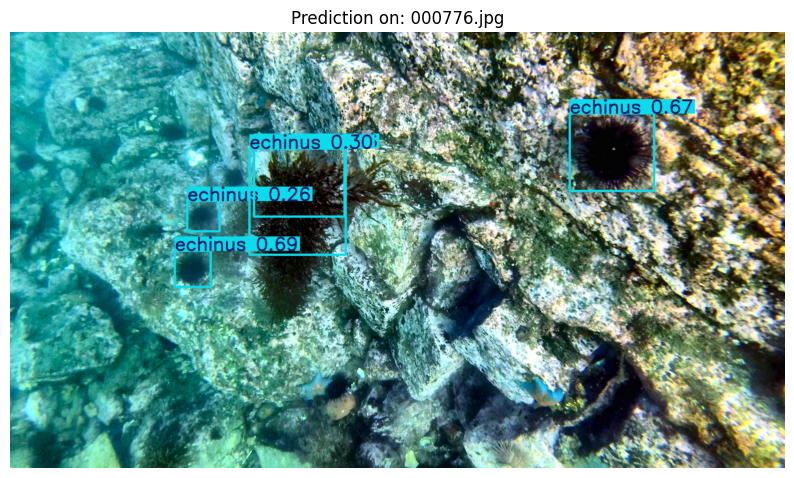

In [ ]:

!pip install ultralytics

import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


!pip install opencv-python-headless

import cv2

EXP17_MODEL_PATH = "/content/best (1).pt"

if not os.path.exists(EXP17_MODEL_PATH):
    print(f" Model not found at: {EXP17_MODEL_PATH}")
else:

    print(f" Loading model: {EXP17_MODEL_PATH}")
    model_exp17 = YOLO(EXP17_MODEL_PATH)


    print("Please upload your test images (.jpg, .png, etc.):")
    uploaded = files.upload()

    if uploaded:
        print(f"\nProcessing {len(uploaded)} images...\n")
        for filename in uploaded.keys():

            results = model_exp17.predict(source=filename, conf=0.25, save=False)


            plotted_img = results[0].plot()
            plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(plotted_img_rgb)
            plt.title(f"Prediction on: {filename}")
            plt.axis('off')
            plt.show()
    else:
        print("No files uploaded.")